<a href="https://colab.research.google.com/github/andysongyz-dev/brown-summer/blob/main/Team4_logistic_regression_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#4E3629;color:#fff;padding:20px 24px;border-radius:8px;font-family:Lato,Arial,Helvetica,sans-serif;"><div style="color:#E9C9C9;font-size:13px;letter-spacing:1.5px;font-weight:bold;">SUMMER@BROWN 2026 &middot; INTRODUCTION TO DATA SCIENCE</div><div style="font-size:27px;font-weight:bold;margin-top:6px;">Assignment 1.3 &mdash; Who Should the Bank Call?</div><div style="font-size:15px;margin-top:6px;color:#f1eae5;">Logistic Regression &middot; Your First Team Project &middot; Python</div><div style="height:4px;background:#990000;margin-top:14px;border-radius:2px;"></div></div>

## The mission
Your team is the new **data science unit at a Portuguese bank**. The bank sells **term deposits** through **phone-call campaigns** — but the call centre **can’t phone everyone**. Using data from past campaigns (45,211 contacts), you’ll build a **logistic regression** model that estimates each client’s *probability* of subscribing, then rank clients so the bank calls the **most promising first**.

The target `y` is binary (subscribed = yes/no), which is exactly what logistic regression is for: it returns a probability between 0 and 1.

<div style="border-left:6px solid #990000;background:#FAF4EC;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#990000;">How this builds on Assignments 1.1 and 1.2</b><br>You already have every tool — this connects them:<ul style="margin:8px 0 0 0;"><li><b>1.2 → missing data:</b> last time you <i>dropped</i> rows; here you’ll <i>impute</i> — and first uncover values hidden as "unknown".</li><li><b>1.2 → hypothesis testing:</b> a t-test on numbers becomes a <b>chi-square test</b> on categories.</li><li><b>1.2 → regression:</b> linear regression predicted a <i>number</i>; logistic regression predicts a <i>probability</i>.</li><li><b>1.2 → train/test &amp; “don’t peek”:</b> the split returns, plus scaling fit on the training set only.</li><li><b>1.1 → storytelling:</b> you’ll finish with a one-paragraph recommendation for the bank.</li></ul></div>

## Working as a team: Colab + GitHub
This is your **first team project**, and collaboration is graded. Use **Google Colab** to write and run code together in real time, and **GitHub** for version control and submission. Edit together in Colab during live sessions; at each milestone use **File → Save a copy in GitHub** to commit, *early and often*.

**Why notebooks fight git:** an `.ipynb` is JSON, so if two people edit the *same cell* and both push you get an ugly merge conflict. Avoid it: one **driver** types during live sessions, each member **owns specific sections**, and **pull before / commit after** you work.

**You’re an international cohort** — coordinating across **time zones** is real. Agree on meeting times *in everyone’s local time* and record them in the charter.

### ✉ Team Charter (fill in before coding)

| Field | Your team’s entry |
|---|---|
| Team number | 4|
| Members (name — **time zone**) | Andy - EST, Mugeng - CST, Edward, PST |
| Section owners | Sections 1-3: Andy, Sections 4-6: Edward, Sections 7, 8, & 10: Mugeng|
| Synchronous meeting times (**each member’s local time**) | |
| Async channel + expected response time | |
| How you’ll avoid notebook merge conflicts | |

**Suggested roles** (everyone writes code *and* answers red questions):
**Data Wrangler** (Sec 1–3) ·
**Analyst** (Sec 4 + 6) ·
**Modeler** (Sec 5 & 7) ·
**Evaluator** (Sec 8–9) ·
**PM / Storyteller** (framing, Sec 10, ReadMe + charter).

## The dataset & what every column means
The file is **`bank-full.csv`** (45,211 rows). **It is semicolon-separated** — read it with `sep=';'`. Here is what each variable means:

| Variable | Meaning | Type |
|---|---|---|
| `age` | Client’s age, in years | numeric |
| `job` | Type of job (admin., technician, management, …) | categorical |
| `marital` | Marital status (married / single / divorced) | categorical |
| `education` | Education level (primary / secondary / tertiary) | categorical |
| `default` | Has credit in default? | yes / no |
| `balance` | Average yearly balance, in euros (can be negative) | numeric |
| `housing` | Has a housing loan? | yes / no |
| `loan` | Has a personal loan? | yes / no |
| `contact` | How the client was contacted (cellular / telephone) | categorical |
| `day` | Day of the month of the last contact | numeric |
| `month` | Month of the last contact (jan … dec) | categorical |
| `duration` | Last call duration, in seconds | numeric — **⚠️ drop it (see below)** |
| `campaign` | # contacts during this campaign for this client | numeric |
| `pdays` | Days since the client was last contacted in a previous campaign | numeric (**−1 = never contacted**) |
| `previous` | # contacts before this campaign | numeric |
| `poutcome` | Outcome of the *previous* campaign (failure / other / success) | categorical |
| **`y`** | **TARGET — did the client subscribe to the term deposit?** | **yes / no** |

<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:12px 16px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Three things to know before you start</b><ul style="margin:8px 0 0 0;"><li><b>"unknown" means missing.</b> In <code>job</code>, <code>education</code>, <code>contact</code>, and <code>poutcome</code>, the value <code>"unknown"</code> is really a missing value in disguise — so you must surface it before you can impute (Section 3).</li><li><b>Drop <code>duration</code>.</b> It’s only known <i>after</i> a call ends, so it can’t help you decide whom to call — and it basically gives away the answer. Keeping it is <b>data leakage</b> (Section 5).</li><li><b><code>pdays = −1</code></b> is a code for “never previously contacted,” not a real day count.</li></ul></div>

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>

## Grading scheme (150 points)

| # | Section | Points |
|---|---|---|
| 1 | Importing libraries & loading data | 10 |
| 2 | Data exploration & descriptive stats | 10 |
| 3 | Surfacing & imputing missing values | 15 |
| 4 | Hypothesis test (chi-square) | 15 |
| 5 | Pre-processing (drop leakage, encode) | 15 |
| 6 | Data visualization | 10 |
| 7 | Model building (split, scale, fit) | 20 |
| 8 | Evaluation (confusion, baseline, ROC/AUC) | 15 |
| 9 | Campaign simulation (who to call) | 10 |
| 10 | Final recommendation (storytelling) | 5 |
| 11 | Red questions | 15 |
| 12 | Teamwork & process | 10 |
| | **Total** | **150** |

**Bonus (up to +10):** +5 for beating the majority-class baseline on **AUC** (not raw accuracy); +5 for an optional Random Forest leaderboard entry.

**How to read this notebook:** markdown intros open each section; <span style="color:#990000"><b>red questions</b></span> are answered in your own words in the cell provided; **`# <Your code here>`** marks where you write code. “Expected output” notes describe the *shape* of the result — match the idea, not every digit.

## 1) Importing libraries

The starter cell imports far more than this notebook needs. **Delete every import you don’t actually use.**

In [1]:
# KEEP ONLY THE LIBRARIES THIS NOTEBOOK ACTUALLY USES; DELETE THE REST.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings





from collections import Counter
from scipy import stats
from scipy.stats import chi2_contingency
import scipy.optimize as opt




from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

### <span style="color:#990000">Q1. Why keep only the libraries the notebook actually uses? Give at least two reasons.</span>

> The first reason is that it keeps our code clear. When we're looking back at our code and see so many unused libraries, we would probably be confused. Another reason is that importing libraries increases the size of the notebook/bundle. We, of course, want to keep the size of our file smaller so it's easier to download and manipulate. A third reason is that security scanners like ones in Github might flag an excessive amount of unused libraries as a threat even if they're totally safe. All the reasons above doesn't just apply to unused libraries but also actual code. When we're converting, migrating, or upgrading, unused code and libraries can get in our way. They're referred to as dead dependencies.  

## 2) Importing the data & descriptive statistics

Load `bank-full.csv` — **remember it is semicolon-separated** — then confirm it imported correctly.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# READ THE DATA  (the file is SEMICOLON-separated!)
# <Your code here>
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/bank-full.csv", sep=";") #save bank-full.csv to your google drive in Colab Notebooks folder

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
TARGET = "y"      # the column that records whether the client subscribed (yes/no)
print("Target column:", TARGET)
print(data.columns.tolist())

Target column: y
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
# 1. DIMENSIONS
# <Your code here>
print(f"rows, columns: {data.shape}")

rows, columns: (45211, 17)


In [6]:
# 2. FIRST 15 ROWS
# <Your code here>
data.head(15)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [7]:
# 3. LAST 5 ROWS
# <Your code here>
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [8]:
# 4. DESCRIPTIVE STATISTICS
# <Your code here>
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 3) Surfacing & imputing missing values

In **1.2** you *dropped* rows with missing data; here every row is a client the bank paid to contact, so we **impute** instead. But first a twist: this dataset hides its missing values as the text **`"unknown"`**. Surface them, *then* impute — mean for numeric, mode for categorical.

**Step 1 (given):** turn the hidden `"unknown"` values into real missing values so pandas can see them.

In [9]:
# Surface the hidden missing values
data = data.replace("unknown", np.nan)

In [10]:
# CHECK FOR MISSING VALUES (per column)
# <Your code here>
data.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [11]:
# IMPUTE NUMERIC COLUMNS WITH THE MEAN
# <Your code here>

#using only numeric columns
numeric_cols = data.select_dtypes(include='number').columns

#imputing mean
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

In [12]:
# IMPUTE CATEGORICAL COLUMNS WITH THE MODE (not the target)
# <Your code here>

#use only categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

#remove target
if 'y' in cat_cols:
  cat_cols.remove('y')

#impute mode
for col in cat_cols:
  data[col] = data[col].fillna(data[col].mode()[0])

In [13]:
# Confirm no missing values remain
print("missing values left:", int(data.isnull().sum().sum()))
data.head(10)

missing values left: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,-1,0,failure,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,-1,0,failure,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,-1,0,failure,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,-1,0,failure,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,-1,0,failure,no
5,35,management,married,tertiary,no,231,yes,no,cellular,5,may,139,1,-1,0,failure,no
6,28,management,single,tertiary,no,447,yes,yes,cellular,5,may,217,1,-1,0,failure,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,cellular,5,may,380,1,-1,0,failure,no
8,58,retired,married,primary,no,121,yes,no,cellular,5,may,50,1,-1,0,failure,no
9,43,technician,single,secondary,no,593,yes,no,cellular,5,may,55,1,-1,0,failure,no


### <span style="color:#990000">Q2. In 1.2 you <i>deleted</i> rows with missing data; here you <i>fill them in</i> — and the data even hid the gaps as "unknown". Why is imputing often better when every row is a client the bank doesn’t want to lose? When might imputing be a bad idea here?</span>

> In 1.2, the data was about exoplanets. If we filled in data instead of deleting rows, that could've caused inconsistencies across individual rows, even using numbers that would disprove Kepler's law. However, in this case, we want to think in the bank's best interest. Even though this might result in more time spent on calling clients, we don't want to lose valuable clients just because their row was missing some data. Although we also have to consider the possibility of us sabotaging our own calls if we impute the wrong data. If we accidentally mark someone who is single as married or someone who has no house as someone who does, we could lose those clients because our calls and services would make no sense.

### <span style="color:#990000">Q3. Why impute the <b>mean</b> for numeric columns but the <b>mode</b> for categorical columns?</span>

> We impute the mean for numeric columns because those variables are continuous and usually fall under the bell curve. Therefore, using the mean would be the safest option to strengthen the quality of our data set while not introducing outliers that offset our data. We use modes for categorical columns because those are classified variables. For example, we can't take the average of classifications like "red", "blue", or "green". Instead, we have to use the mode which represents the most frequently appearing observation/classification in that column.

## 4) Hypothesis test (chi-square) — callback to 1.2

Test a hunch the way you did in 1.2, but for **categorical** data, using a **chi-square test of independence**: *is the outcome of the previous campaign (`poutcome`) associated with subscribing now?* Run it **before** encoding.

In [14]:
feature = "poutcome"     # try others too, e.g. "job" or "housing"

# 1. Contingency table: feature vs TARGET
# <Your code here>      # pd.crosstab(data[feature], data[TARGET])
table = pd.crosstab(data[feature], data[TARGET])
print(table)
print()

# 2. Chi-square test of independence
# <Your code here>      # chi2, p, dof, expected = chi2_contingency(table)
chi2, p, dof, expected = chi2_contingency(table)

# 3. Print the chi-square statistic and the p-value
# <Your code here>
print(f"chi-square = {chi2:.1f} p-value = {p:.3e} dof = {dof}")

y            no   yes
poutcome             
failure   37856  4004
other      1533   307
success     533   978

chi-square = 4341.7 p-value = 0.000e+00 dof = 2


### <span style="color:#990000">Q4. State H₀ and H₁ for this test. Based on the p-value, at the 0.05 level is `poutcome` associated with subscribing? What does that mean for the bank?</span>

> H₀ is that there is no assocation between past outcome and subscribing. H₁ is that there is an association between past outcome and subscribing. Based on the p-value of 0, there is a strong association between past outcome and subscribing. For the bank, that means further testing must be done to see whether this association is positive or negative, but intuitively it seems to be a positive correlation.

## 5) Pre-processing: drop leakage, then encode

**Step 1 (given) — drop `duration`.** Call duration is only known *after* the call, so it can’t inform *whom to call*, and it all but reveals the outcome. Keeping it is **data leakage**.

In [15]:
data = data.drop(columns=["duration"])

### <span style="color:#990000">Q5. Why must we drop `duration` for a model that decides <i>whom to call</i>? What kind of mistake is keeping it, and what would happen to our scores if we left it in?</span>

>We must drop duration for a model that decides whom to call because the duration of a call can't possibly be known until after the call, and it can create irrelevant and misleading correlations between duration of the call and probability to subscribe. This kind of mistake is a data leakage, and our scores could get moved up or down depending on the data.

**Step 2 — encode.** Label-encode the **target** to a single 0/1 column; one-hot encode the categorical **features** only (don’t leak the target).

In [16]:
y_series = data[TARGET].map({"yes": 1, "no": 0})

# --- FEATURES: one-hot encode categorical FEATURES only ---
features = data.drop(columns=[TARGET])
ohe = OneHotEncoder(sparse_output=False)   # current scikit-learn uses sparse_output (not sparse=)
data_transformed = pd.DataFrame(index=features.index)

for column in features.columns:
    if features[column].dtype == "object":
        # one-hot encode this categorical feature; name columns like column_value
        encoded_data = ohe.fit_transform(features[[column]])
        column_names = ohe.get_feature_names_out([column])
        data_transformed[column_names] = encoded_data

    else:
        # numeric column: copy across unchanged
        data_transformed[column] = features[column]


data_transformed[TARGET] = y_series.values
data = data_transformed
data.head(10)

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_nov,month_oct,month_sep,campaign,pdays,previous,poutcome_failure,poutcome_other,poutcome_success,y
0,58,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
1,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
2,33,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
3,47,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
4,33,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
5,35,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
6,28,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
7,42,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
8,58,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
9,43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0


### <span style="color:#990000">Q6. Why one-hot encode the features but label-encode the target? What could go wrong if you one-hot encoded the target instead?</span>

> We have to one-hot encode the features because just assigning numbers to different categories can cause confusions with our models. The numbers we assign can mislead the model into thinking that the categories have different weights. One-hot encoding eliminates this confusion. We don't one-hot encode the feature, but instead label-encode it, because we want a single outcome for each row. By one-hot encoding it, we're creating multiple columns and the model might try to predict mutiple things at once like yes AND no.

## 6) Data visualization

Plot **histograms** of every column, then a correlation **heatmap**. *Expected output:* a grid of histograms and a coloured heatmap.

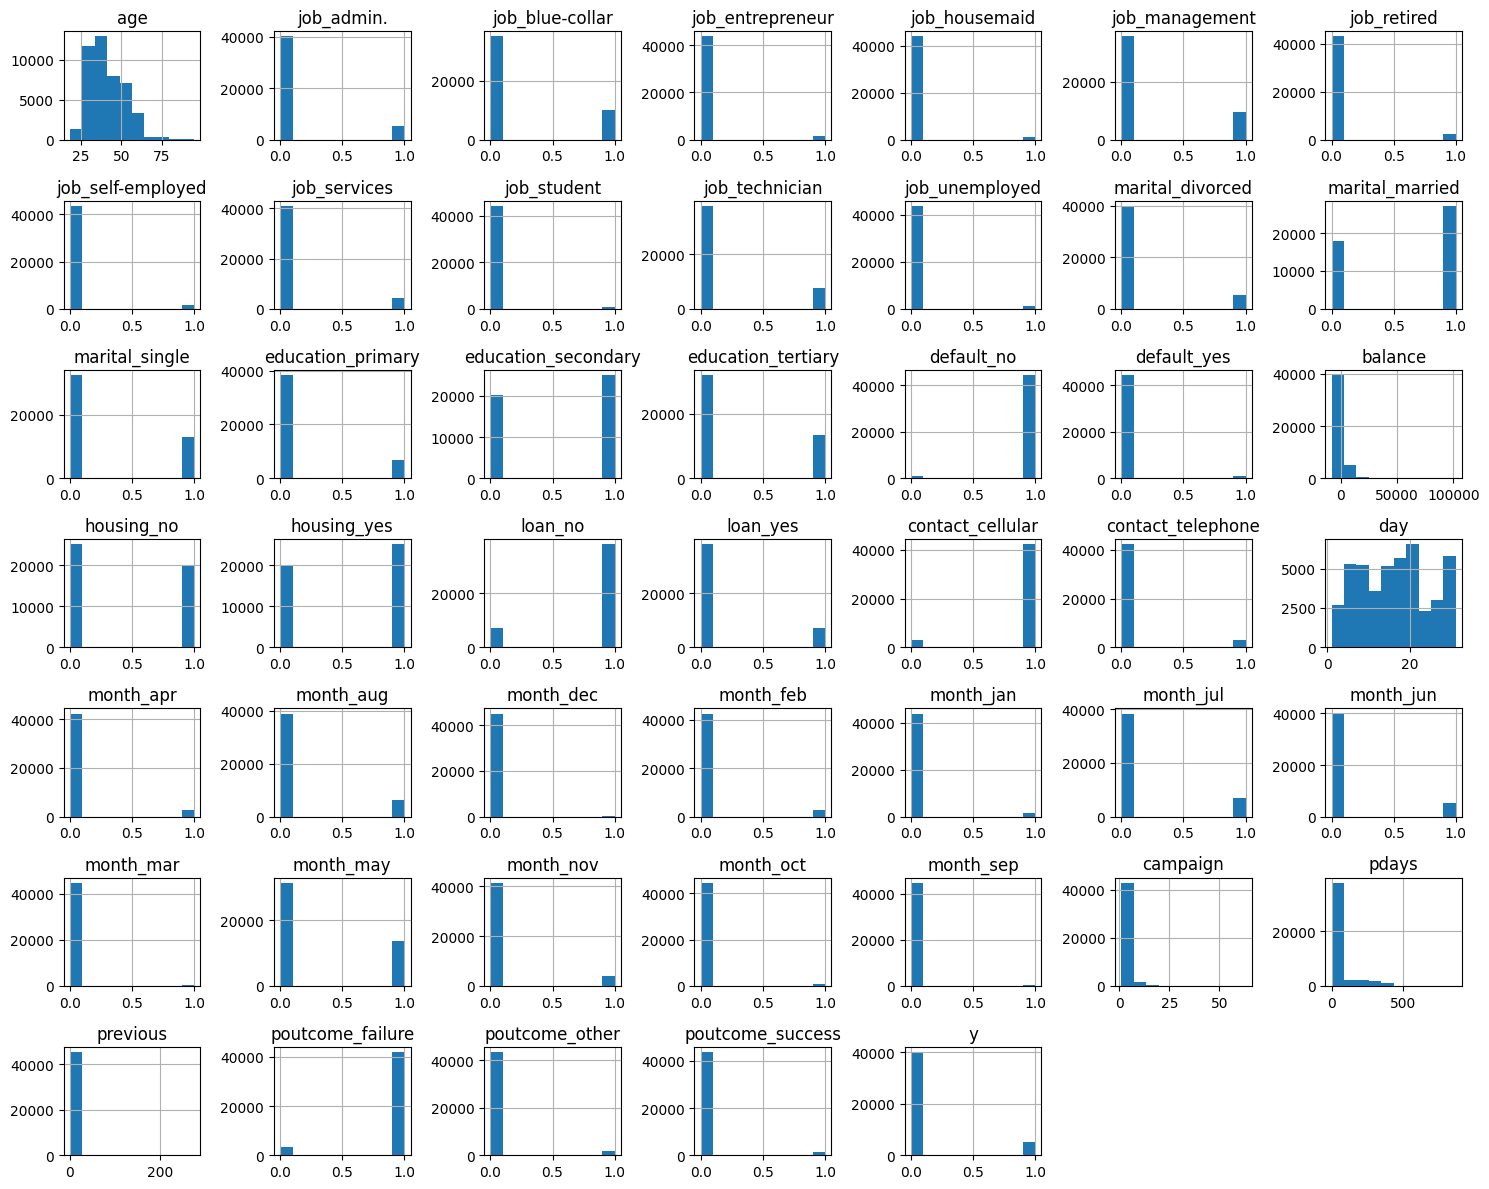

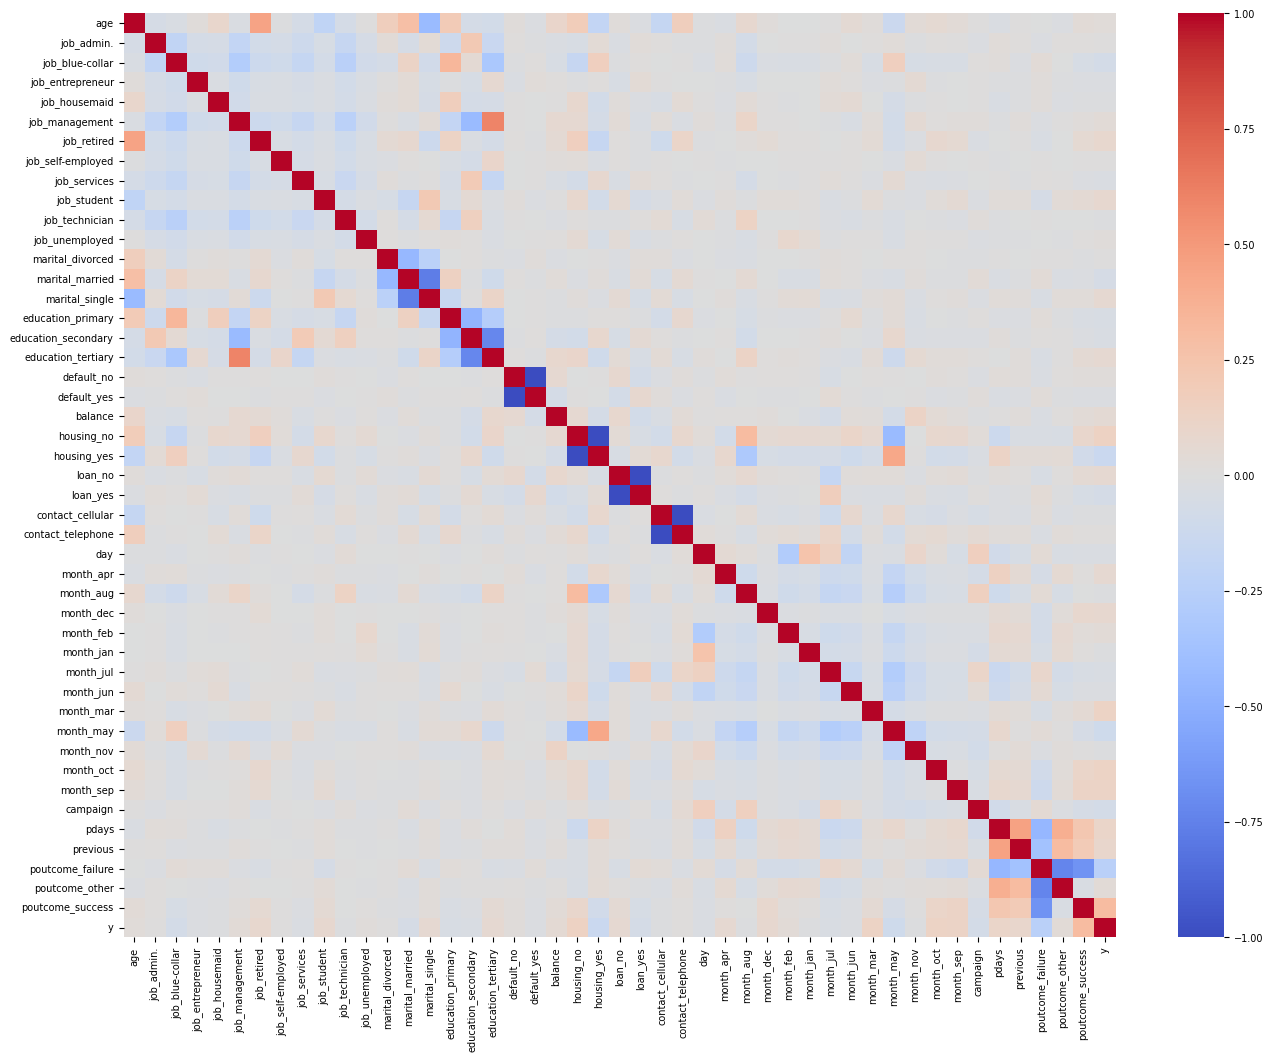

In [17]:
# HISTOGRAMS
# <Your code here>      # data.hist(figsize=(15, 12))
data.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

# CORRELATION MATRIX + HEATMAP
plt.rcParams["font.size"] = 7
# <Your code here>
plt.figure(figsize=(16,12))
sns.heatmap(data.corr(), annot=False, cmap="coolwarm", fmt = ".2f")
plt.show()

### <span style="color:#990000">Q7. Describe the histograms — which features are skewed?</span>

> All the features except day and age appear to be skewed. However, if you interpret the one-hot encoded variables as normal variables, then only education would be skewed towards secondary, marital status would be skewed towards married, default would be skewed towards no, loan would be skewed towards no, contact would be skewed towards cellular, and poutcome would be skewed towards failure.

### <span style="color:#990000">Q8. What does the correlation heatmap reveal? Is any single feature strongly correlated with the target?</span>

> The heatmap reveals that there's no single feature that's strongly correlated with the target. The variable that is most strongly correlated with the target is poutcome_success, which is still only around 0.35. poutcome_failure has the strongest negative correlation with the target variable, at around -0.2. THese are weak correlations, but they make sense considering if a past call failed, a call would be less likely to succeed, and if a past call succeeded, a call would be more likely to succeed

## 7) Model building

Recall from **1.2**: linear regression drew a line for a *number*; logistic regression bends it into an **S-curve** so the output is a probability in [0, 1].

In [18]:
# 1. FEATURES (X) AND TARGET (y)
# <Your code here>
X = data.drop(columns=[TARGET])
y = data[TARGET]
# 2. TRAIN / TEST SPLIT (test_size=0.2, random_state=42, stratify=y)
# <Your code here>
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
# 3. SCALE — fit on TRAIN ONLY, then transform both
scaler = MinMaxScaler()
# <Your code here>      # X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train)
# <Your code here>      # X_test_scaled  = scaler.transform(X_test)
X_test_scaled = scaler.transform(X_test)
# 4. FIT LOGISTIC REGRESSION
logreg = LogisticRegression(max_iter=2000)
# <Your code here>
logreg.fit(X_train_scaled, y_train)

print(f"trained on {X_train.shape[0]} clients, {X_train.shape[1]} features")

trained on 36168 clients, 46 features


### <span style="color:#990000">Q9. Why split into train and test sets? And why fit the scaler on the <b>training</b> set only?</span>

We split the data so we evaluate whether our model performs well on unseen data, where the training set is used to teach the model patterns, and the test set is used to simulate real world performance on new data which the model has not seen. If we don't split and train the data, the model might have the risk of overfitting, where the model has high training accuracy and low test accuracy, because we end up testing the model with data it has already memorized. We fit the scaler only on the training set to prevent data leakage, and if we fit the full dataset, the scaler would have already seen the test data and so the evaluation would be unrealistic.

## 8) Model evaluation

**Accuracy can lie** when one class is rare. Print accuracy and the confusion matrix, compute the **lazy baseline**, then plot the **ROC curve / AUC**.

In [19]:
# PREDICT + ACCURACY
# <Your code here>
from sklearn.metrics import accuracy_score
y_pred = logreg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
# CONFUSION MATRIX
# <Your code here>
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

Accuracy: 0.8939511224151278
Confusion Matrix:

[[7893   92]
 [ 867  191]]


In [20]:
# THE LAZY BASELINE: predict the majority class for everyone
# <Your code here>      # y_test.value_counts(normalize=True).max()
baseline = y_test.value_counts(normalize=True).max()
print("Lazy baseline accuracy:", baseline)

Lazy baseline accuracy: 0.8830034280659074


AUC: 0.7511664711598898


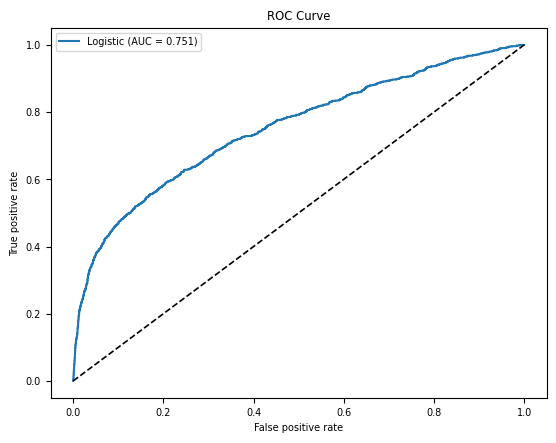

In [21]:
# ROC CURVE + AUC (use predicted PROBABILITIES)
#probs = None   # <Your code here>   logreg.predict_proba(X_test_scaled)[:, 1]
from sklearn.metrics import roc_curve, roc_auc_score
probs = logreg.predict_proba(X_test_scaled)[:,1]
# <Your code here>      # fpr, tpr, thresholds = roc_curve(y_test, probs)
fpr, tpr, thresholds = roc_curve(y_test, probs)
# <Your code here>      # auc = roc_auc_score(y_test, probs)
auc = roc_auc_score(y_test, probs)
# plot the ROC curve, labelled with the AUC, plus the diagonal
# <Your code here>
print("AUC:", auc)
plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="black", linewidth=1.2)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### <span style="color:#990000">Q10. About 12% of clients subscribe, so predicting “no” for everyone already scores ~88%. What did your lazy baseline get, how close is the model’s accuracy, and what does <b>AUC</b> capture that accuracy misses?</span>

The lazy baseline accuracy was about 88.3%, while the logistic regression model achieved 89.4% and about 1.1% higher than baseline. This shows that accuarcy alone is not a strong evaluation metric for this imbalenced dataset because a model can achieve high accuracy by mostly predciting the majority class. Unlike accuracy, the AUC of 0.751 can measure how well the model ranks clients by their proability of subcribing across different thresholds.


## 9) Campaign simulation: who should the bank call?

Turn the model into a decision. Rank the **test** clients by predicted probability, “call” the **top 20%**, and compare subscribers reached vs calling 20% **at random**.

In [22]:
budget = 0.20   # the call centre can phone the top 20%

# 1. table of each test client's true label and predicted probability
# <Your code here>
#ONLY WORKS AFTER LOGISTIC REGRESSION IS DONE AND VARIABLE MATCHES
df_sim = pd.DataFrame({"true_label": y_test, "probability": probs})

# 2. sort by probability (highest first) and take the top 20%
# <Your code here>
df_sorted = df_sim.sort_values(by="probability", ascending = False)
num_calls = int(len(df_sorted) * budget)
top_20_percent = df_sorted.head(num_calls)

# 3. how many ACTUAL subscribers are in that top 20%?
# <Your code here>
model_subscribers = top_20_percent["true_label"].sum()
total_subscribers = int(y_test.sum())
pct_reached = (model_subscribers / total_subscribers) * 100

# 4. how many subscribers would 20% AT RANDOM reach?
# <Your code here>
random_subscribers = int(round(total_subscribers * budget))

# 5. print both and the lift (model / random)
# <Your code here>
lift = model_subscribers / (total_subscribers * budget)

print(f"Calling the top 20% the MODEL ranks highest reaches {model_subscribers} of {total_subscribers} subscribers ({pct_reached:.0f}% of them).")
print(f"Calling 20% at RANDOM would reach about {random_subscribers}.")
print(f"Lift = {lift:.2f}x")

Calling the top 20% the MODEL ranks highest reaches 564 of 1058 subscribers (53% of them).
Calling 20% at RANDOM would reach about 212.
Lift = 2.67x


## 10) Recommendation to the bank (storytelling)

### <span style="color:#990000">Q11. In 3–5 sentences for a bank manager (no jargon): whom should the bank call first, and roughly how much better is your model than calling at random? Name one honest limitation.</span>

The bank should call the clients that the model ranks as having the highest likelihood of subscribing. By focusing on the top 20% of clients, the model reached about 53% of it subcribers, compared with only about 20% of subscribers expected from random calling, giving the bank about 2.67x improvment. This means the call centre can use its limited time more efficiently by priortizing their time to call the clients that are more likely to subscribe. One limitation is that the model might still miss potential subscribers, since it only identifies patterns from past campaigns.


<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Section 11 — Stretch goal (optional, leaderboard / bonus)</b> — the core deliverable is your logistic pipeline. If you finish early, train a Random Forest and compare its AUC. Skipping it costs nothing.</div>

Random forest accuracy: 0.8933


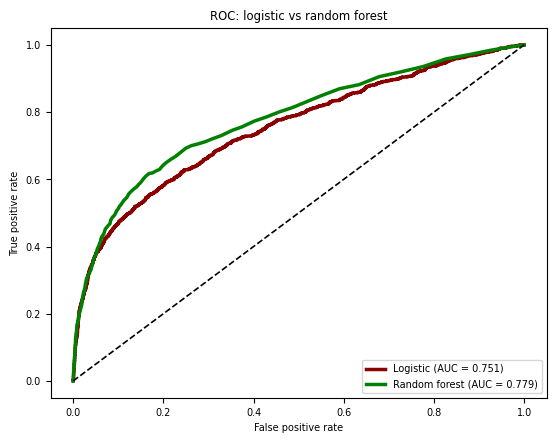

In [23]:
# OPTIONAL — Random Forest
#rf = RandomForestClassifier(n_estimators=200, random_state=42)
# <Your code here>      # rf.fit(...)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# accuracy, then probabilities -> ROC + AUC, plotted against logistic
# <Your code here>
y_pred_rf = rf.predict(X_test) #accuracy
print(f"Random forest accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

#probabilities
probs_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
auc_rf = roc_auc_score(y_test, probs_rf)


#ONLY WORKS AFTER LOGISTIC REGRESSION IS DONE AND VARIABLE MATCHES
plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc:.3f})", color="darkred", linewidth=2.5)

plt.plot(fpr_rf, tpr_rf, label=f"Random forest (AUC = {auc_rf:.3f})", color = "green", linewidth=2.5)

plt.plot([0,1], [0,1], linestyle="--", color="black", linewidth=1.2)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC: logistic vs random forest")
plt.legend(loc="lower right")

plt.show()





### <span style="color:#990000">Q12. (Optional) How did the Random Forest’s AUC compare? Which model would you ship to the bank, and why?</span>

The Random Forest model achived a slightly higher AUC (0.779) compared to logistic regression (0.751), meaning it was better at ranking clients by their likelihood of subscribing. Considering shipping the Random Forest to the bank could be advantageous since the higher AUC suggests that it may improve in targeting.


## 12) Team retrospective

### <span style="color:#990000">Q13. What broke in your collaboration — a merge conflict, a missed meeting across time zones, a version mismatch, uneven workload — and how did you fix it? What will you do differently next time?</span>

All of the team members are working in a different time zone and it is hard to coordinate especially when Slack isn't working for all of the team members. Because of communication difficulties and team members starting the assignment on different times, the workload is distributed unevenly between the team members. Next time, distributing work sections before starting the assignments, setting up deadlines, and reviewing the work together when the assignment is done would improve our efficiency. We also would establish response times in order to boost efficiency and make sure that everyone is on the same page.

## Deliverables & submission

- Submit the completed **`.ipynb`**, named with your team number, via **GitHub** (e.g. **`Team7_logistic_regression_1_3.ipynb`**).
- Include a **`ReadMe.txt`** with members’ names, your **team charter** (times *with time zones*, section owners), and a **contribution log** (each member: what they did + their commits).
- **Before submitting:** **Runtime → Restart and run all** so the notebook runs top-to-bottom with no errors.
- Give repo access to **`gk2311`** on GitHub and paste the link in the Canvas submission.

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>